<a href="https://www.kaggle.com/code/aminebcf/is-the-song-a-hit-machine-leaning-prediction?scriptVersionId=313397425" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Leak-free Modeling Pipeline (Spotify)
This notebook rebuilds the modeling workflow using an sklearn `Pipeline` + `ColumnTransformer` so that **all preprocessing is fit on the training set only**.

Key differences vs a typical quick notebook:
- Split first (train/val/test)
- Fit scaler/encoder on train only
- Avoid undersampling unless you explicitly want it (we use `class_weight='balanced'`)

Target used here:
- `is_hit = 1` if `popularity > 50` (raw popularity is 0–100)

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    AdaBoostClassifier,
 )
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    RocCurveDisplay,
    average_precision_score,
    PrecisionRecallDisplay,
    log_loss,
 )

In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/anbudanadithya/spotify-music/Spotify_Music.csv


In [3]:
# Load data (works both locally and on Kaggle)
import os

local_csv = 'Spotify_Music.csv'
kaggle_csv = '/kaggle/input/datasets/anbudanadithya/spotify-music/Spotify_Music.csv'

if os.path.exists(local_csv):
    df_raw = pd.read_csv(local_csv)
    print('Loaded LOCAL CSV:', local_csv)
else:
    df_raw = pd.read_csv(kaggle_csv)
    print('Loaded KAGGLE CSV:', kaggle_csv)

print('shape:', df_raw.shape)
display(df_raw.head())

Loaded KAGGLE CSV: /kaggle/input/datasets/anbudanadithya/spotify-music/Spotify_Music.csv
shape: (114000, 21)


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [4]:
# Drop high-cardinality text identifiers (they're not audio features)
drop_cols = ['track_id', 'artists', 'album_name', 'track_name', 'Unnamed: 0']
df = df_raw.drop(columns=drop_cols, errors='ignore').copy()

# Define target from raw popularity (0..100)
if 'popularity' not in df.columns:
    raise ValueError('Expected a popularity column in the dataset.')

df['is_hit'] = (df['popularity'] > 50).astype(int)

# Features: exclude popularity/label and (optionally) genre for an audio-only baseline
X = df.drop(columns=['popularity', 'is_hit', 'track_genre'], errors='ignore')
y = df['is_hit']

print('X shape:', X.shape)
print('y mean (hit rate):', y.mean())
y.value_counts().sort_index()

X shape: (114000, 14)
y mean (hit rate): 0.24359649122807017


is_hit
0    86230
1    27770
Name: count, dtype: int64

In [5]:
# 70% train, 15% val, 15% test (stratified)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print('train:', X_train.shape, 'hit rate:', y_train.mean())
print('val:  ', X_val.shape, 'hit rate:', y_val.mean())
print('test: ', X_test.shape, 'hit rate:', y_test.mean())

# --- Force perfect 50/50 class balance by DELETING rows (downsampling) on TRAIN only ---
BALANCE_TRAIN_50_50 = True
BALANCE_RANDOM_STATE = 42

X_train_full, y_train_full = X_train, y_train
if BALANCE_TRAIN_50_50:
    vc = y_train_full.value_counts().sort_index()
    if set(vc.index) != {0, 1}:
        raise ValueError(f'Expected binary labels {{0,1}}, got counts: {vc.to_dict()}')
    n = int(vc.min())
    rng = np.random.default_rng(BALANCE_RANDOM_STATE)

    idx0 = y_train_full[y_train_full == 0].sample(n=n, random_state=BALANCE_RANDOM_STATE).index.to_numpy()
    idx1 = y_train_full[y_train_full == 1].sample(n=n, random_state=BALANCE_RANDOM_STATE).index.to_numpy()
    idx = np.concatenate([idx0, idx1])
    rng.shuffle(idx)

    X_train = X_train_full.loc[idx]
    y_train = y_train_full.loc[idx]

    print('\nBalanced TRAIN to 50/50 by downsampling:')
    print('train (balanced):', X_train.shape, 'hit rate:', y_train.mean())
    print('train label counts:', y_train.value_counts().sort_index().to_dict())

train: (79800, 14) hit rate: 0.24359649122807017
val:   (17100, 14) hit rate: 0.24362573099415205
test:  (17100, 14) hit rate: 0.2435672514619883

Balanced TRAIN to 50/50 by downsampling:
train (balanced): (38878, 14) hit rate: 0.5
train label counts: {0: 19439, 1: 19439}


In [6]:
# Auto-detect columns for preprocessing
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = [c for c in X_train.columns if c not in cat_cols]

print('categorical:', cat_cols)
print('numeric:', len(num_cols))

numeric_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', MinMaxScaler()),
])

categorical_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')),
])

preprocess = ColumnTransformer(
    transformers=[
        ('num', numeric_pipe, num_cols),
        ('cat', categorical_pipe, cat_cols),
    ],
    remainder='drop',
)

categorical: []
numeric: 14


Using class_weight: None

--- Training: LogReg (Ridge/L2) ---

==== LogReg (Ridge/L2) ====
Fit time: 0.88s
Validation report:
              precision    recall  f1-score   support

           0     0.8178    0.5440    0.6534     12934
           1     0.3058    0.6236    0.4104      4166

    accuracy                         0.5634     17100
   macro avg     0.5618    0.5838    0.5319     17100
weighted avg     0.6930    0.5634    0.5942     17100

Confusion matrix (val):
[[7036 5898]
 [1568 2598]]


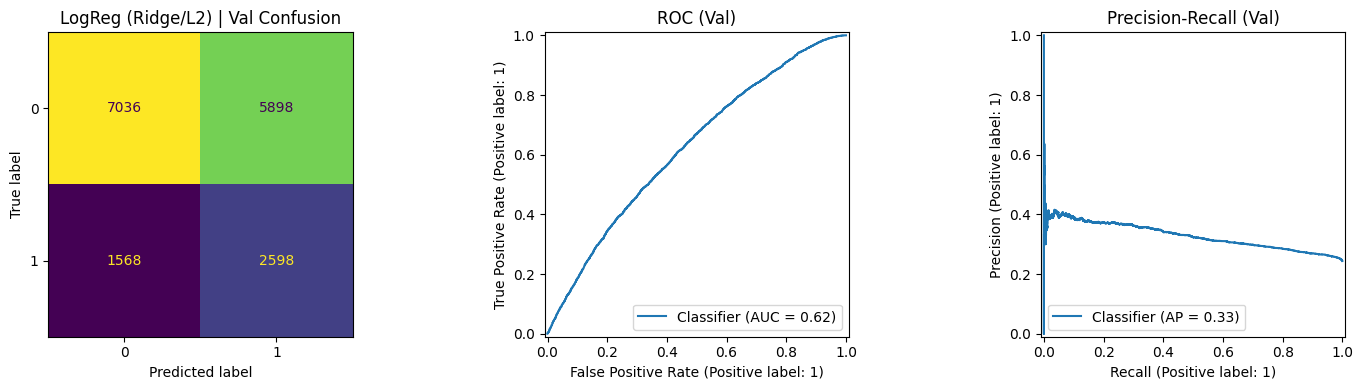


--- Training: LogReg (Lasso/L1) ---

==== LogReg (Lasso/L1) ====
Fit time: 0.56s
Validation report:
              precision    recall  f1-score   support

           0     0.8179    0.5435    0.6530     12934
           1     0.3058    0.6243    0.4105      4166

    accuracy                         0.5632     17100
   macro avg     0.5618    0.5839    0.5318     17100
weighted avg     0.6931    0.5632    0.5939     17100

Confusion matrix (val):
[[7029 5905]
 [1565 2601]]


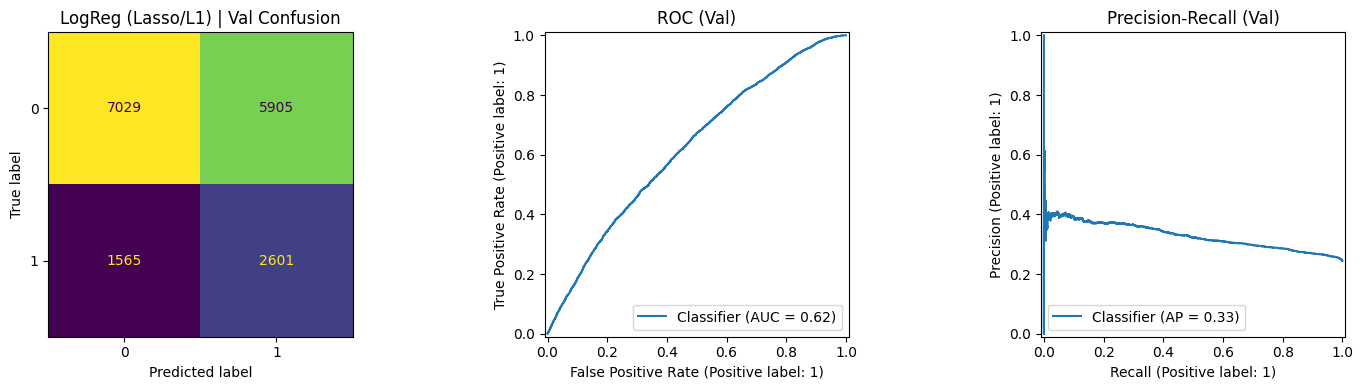


--- Training: Random Forest ---

==== Random Forest ====


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:    2.5s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    5.9s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.1s


Fit time: 6.07s


[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    0.3s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.1s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    0.3s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.1s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    0.1s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.1s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    0.2s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.1s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    0.2s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Paral

Validation report:
              precision    recall  f1-score   support

           0     0.8972    0.7285    0.8041     12934
           1     0.4678    0.7408    0.5734      4166

    accuracy                         0.7315     17100
   macro avg     0.6825    0.7347    0.6888     17100
weighted avg     0.7926    0.7315    0.7479     17100

Confusion matrix (val):
[[9423 3511]
 [1080 3086]]


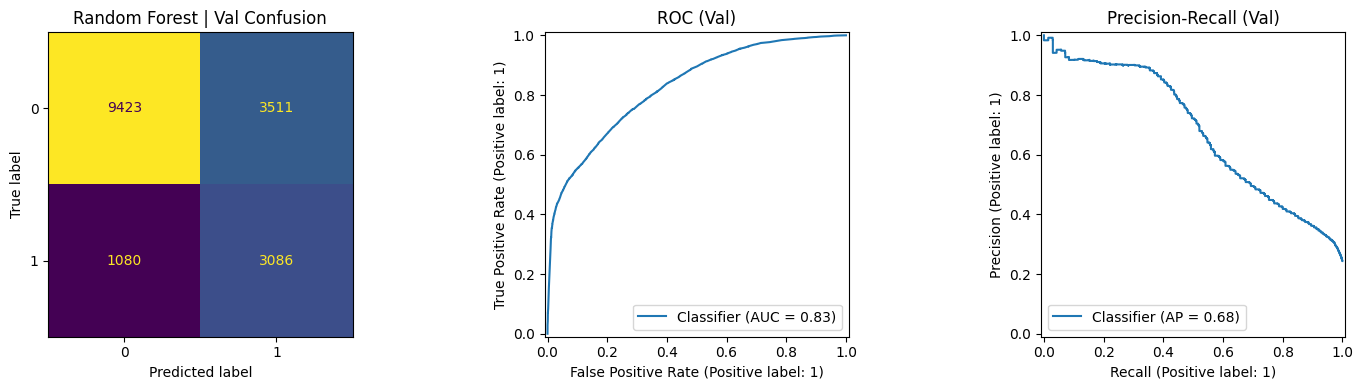


--- Training: Gradient Boosting ---

==== Gradient Boosting ====
Fit time: 14.05s
Validation report:
              precision    recall  f1-score   support

           0     0.8507    0.5531    0.6704     12934
           1     0.3349    0.6985    0.4527      4166

    accuracy                         0.5885     17100
   macro avg     0.5928    0.6258    0.5615     17100
weighted avg     0.7250    0.5885    0.6173     17100

Confusion matrix (val):
[[7154 5780]
 [1256 2910]]


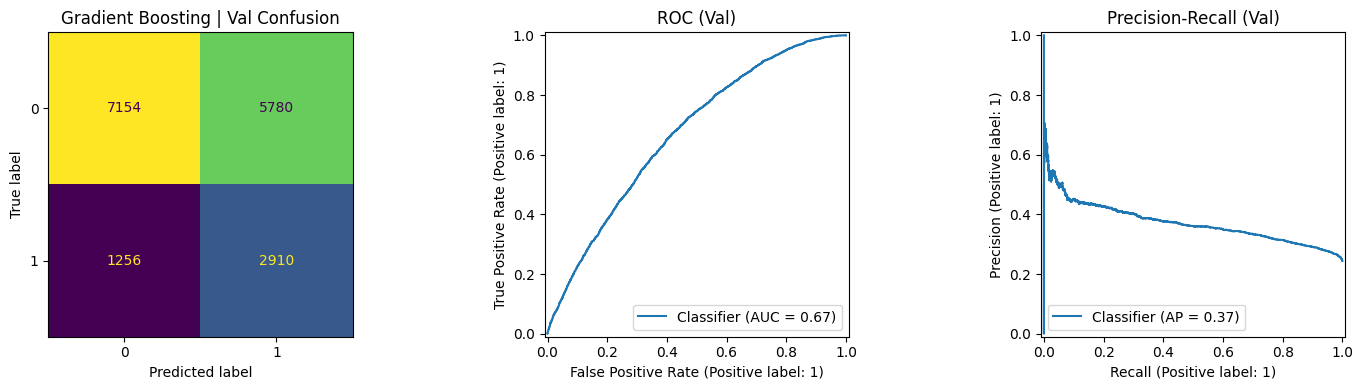


--- Training: HistGradientBoosting (L2 ridge) ---

==== HistGradientBoosting (L2 ridge) ====
Fit time: 0.80s
Validation report:
              precision    recall  f1-score   support

           0     0.8639    0.5901    0.7012     12934
           1     0.3585    0.7112    0.4767      4166

    accuracy                         0.6196     17100
   macro avg     0.6112    0.6507    0.5890     17100
weighted avg     0.7407    0.6196    0.6465     17100

Confusion matrix (val):
[[7633 5301]
 [1203 2963]]


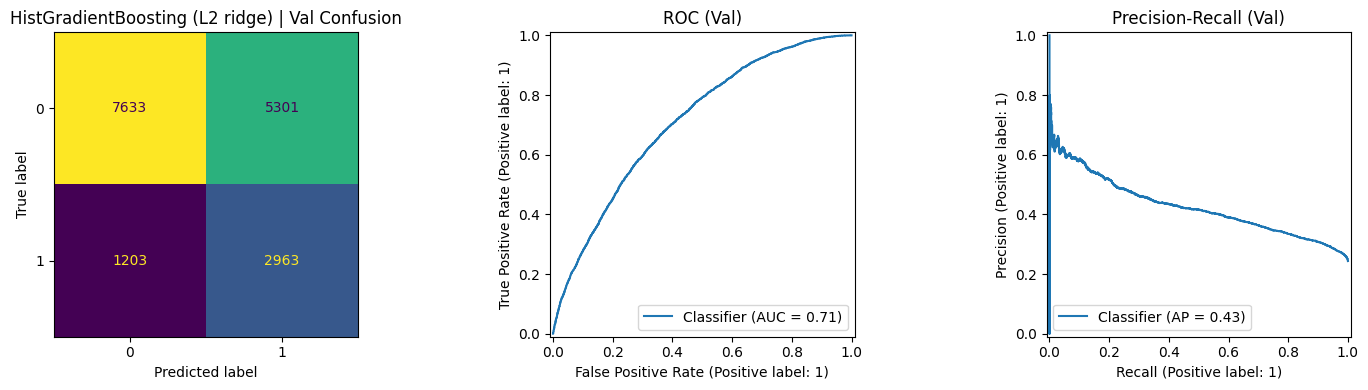


--- Training: AdaBoost ---

==== AdaBoost ====
Fit time: 2.84s
Validation report:
              precision    recall  f1-score   support

           0     0.8240    0.5236    0.6403     12934
           1     0.3062    0.6529    0.4169      4166

    accuracy                         0.5551     17100
   macro avg     0.5651    0.5882    0.5286     17100
weighted avg     0.6979    0.5551    0.5859     17100

Confusion matrix (val):
[[6772 6162]
 [1446 2720]]


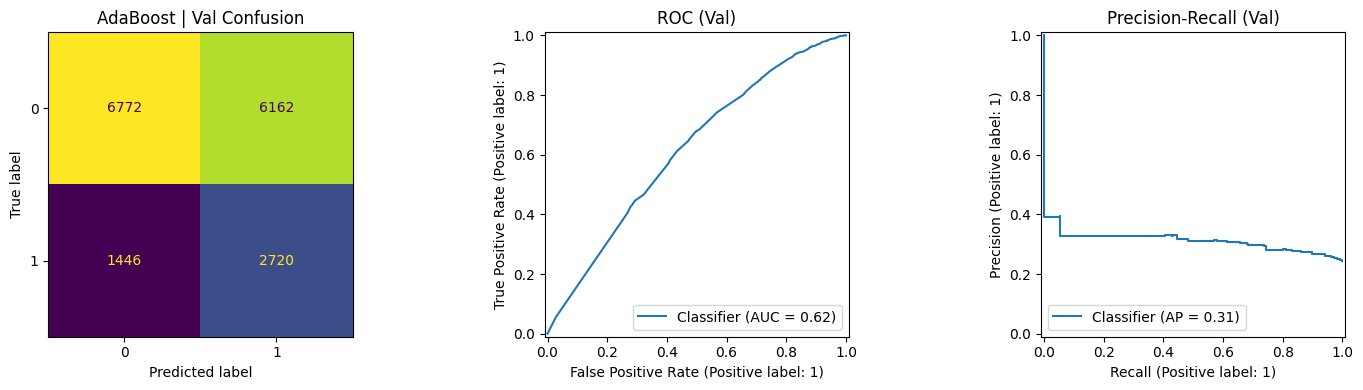


--- Training: Linear SVM (calibrated) ---

==== Linear SVM (calibrated) ====
Fit time: 0.79s
Validation report:
              precision    recall  f1-score   support

           0     0.8179    0.5458    0.6547     12934
           1     0.3063    0.6227    0.4106      4166

    accuracy                         0.5646     17100
   macro avg     0.5621    0.5843    0.5327     17100
weighted avg     0.6933    0.5646    0.5953     17100

Confusion matrix (val):
[[7060 5874]
 [1572 2594]]


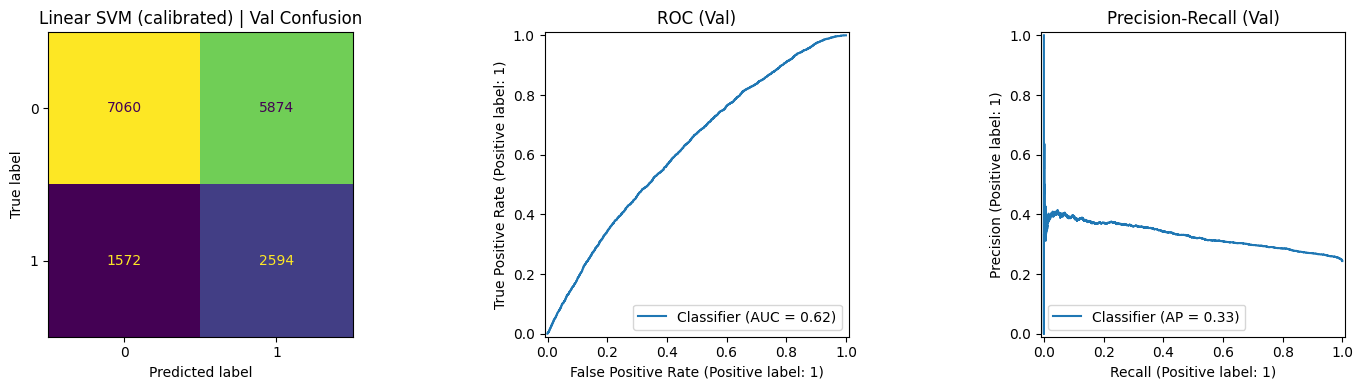

,Model,Fit Seconds,Train Acc,Val Acc,Test Acc,Train Bal Acc,Val Bal Acc,Test Bal Acc,Train Precision,Val Precision,...,Test F1,Train ROC AUC,Val ROC AUC,Test ROC AUC,Train PR AUC,Val PR AUC,Test PR AUC,Train Loss,Val Loss,Test Loss
2,Random Forest,6.068353,0.992026,0.731520,0.727251,0.992026,0.734652,0.731728,0.992990,0.467788,...,0.569424,0.999098,0.828245,0.828471,0.999279,0.679275,0.681652,0.153218,0.524411,0.519907
4,HistGradientBoosting (L2 ridge),0.804030,0.712871,0.619649,0.624269,0.712871,0.650692,0.658285,0.688313,0.358543,...,0.484391,0.789006,0.710815,0.715087,0.773657,0.425346,0.432030,0.575377,0.622327,0.622622
3,Gradient Boosting,14.051033,0.636633,0.588538,0.586608,0.636633,0.625814,0.625984,0.619661,0.334868,...,0.452991,0.692421,0.670504,0.677167,0.666256,0.371857,0.382183,0.633084,0.646029,0.645140
5,AdaBoost,2.844452,0.588868,0.555088,0.550117,0.588868,0.588243,0.582736,0.578648,0.306237,...,0.411715,0.618082,0.616116,0.615237,0.584356,0.311118,0.310321,0.673893,0.674479,0.674844
6,Linear SVM (calibrated),0.790089,0.586579,0.564561,0.566140,0.586579,0.584254,0.587060,0.580588,0.306330,...,0.413471,0.624333,0.622644,0.622082,0.605090,0.328112,0.327132,0.666814,0.669333,0.668767
1,LogReg (Lasso/L1),0.556809,0.585858,0.563158,0.564971,0.585858,0.583896,0.587183,0.579590,0.305784,...,0.413837,0.624151,0.622240,0.622231,0.605331,0.328097,0.327575,0.666785,0.669407,0.668670
0,LogReg (Ridge/L2),0.879597,0.587530,0.563392,0.565673,0.587530,0.583806,0.587565,0.581144,0.305791,...,0.414136,0.624302,0.622590,0.622339,0.605072,0.328241,0.327681,0.666941,0.669372,0.668687


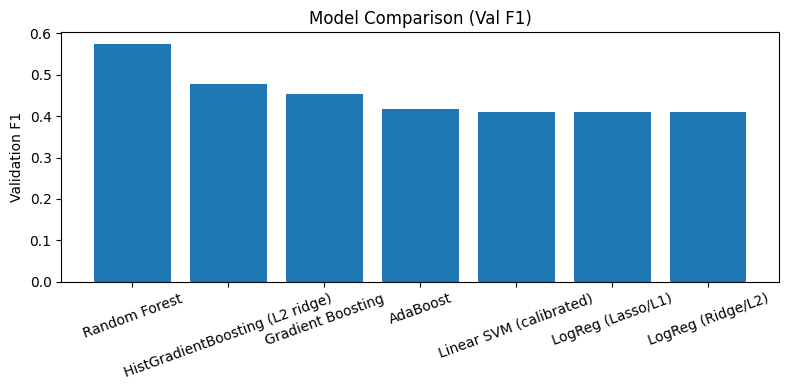

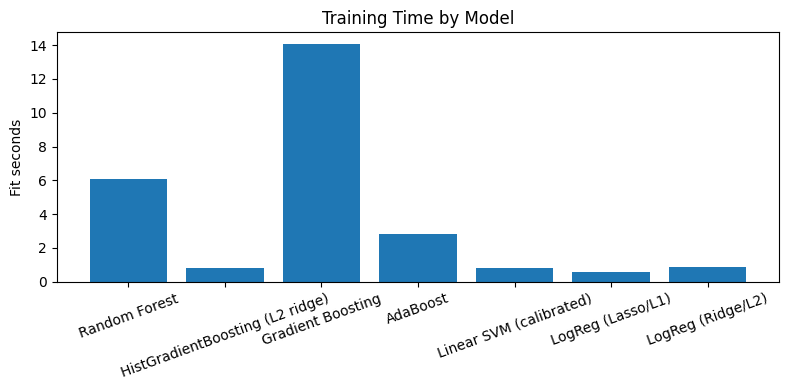

In [7]:
# Models (no undersampling; optional downsampling to 50/50 is handled in the split cell)
use_class_weight = not (('BALANCE_TRAIN_50_50' in globals()) and bool(BALANCE_TRAIN_50_50))
cw = 'balanced' if use_class_weight else None
print('Using class_weight:', cw)

# --- Regularization knobs ---
# In sklearn LogisticRegression, C is inverse regularization strength: lambda ~= 1/C
RIDGE_C = 1.0   # L2 (ridge) strength: smaller C => stronger penalty
LASSO_C = 0.5   # L1 (lasso) strength: smaller C => stronger penalty
HGB_L2 = 0.1    # HistGradientBoosting L2 (ridge-like) regularization strength

models = {
    # Penalized linear models
    'LogReg (Ridge/L2)': LogisticRegression(
        max_iter=5000, class_weight=cw, penalty='l2', C=RIDGE_C, solver='lbfgs'
    ),
    'LogReg (Lasso/L1)': LogisticRegression(
        max_iter=5000, class_weight=cw, penalty='l1', C=LASSO_C, solver='saga', n_jobs=-1
    ),
    # Tree models
    # verbose>0 prints tree-building progress; n_jobs=-1 uses all cores
    'Random Forest': RandomForestClassifier(
        random_state=42,
        n_jobs=-1,
        class_weight=cw,
        verbose=1,
    ),
    # Boosting models
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'HistGradientBoosting (L2 ridge)': HistGradientBoostingClassifier(
        random_state=42,
        learning_rate=0.1,
        max_depth=None,
        l2_regularization=HGB_L2,
    ),
    'AdaBoost': AdaBoostClassifier(random_state=42),
    # Linear margin model (calibrated so we can use predict_proba downstream)
    'Linear SVM (calibrated)': CalibratedClassifierCV(
        estimator=LinearSVC(random_state=42, max_iter=20000, class_weight=cw),
        method='sigmoid',
        cv=3,
    ),
}

def evaluate(name, pipe, X_tr, y_tr, X_va, y_va, X_te, y_te):
    print(f'\n==== {name} ====')
    t0 = time.perf_counter()
    pipe.fit(X_tr, y_tr)
    fit_s = time.perf_counter() - t0
    print(f'Fit time: {fit_s:.2f}s')

    def _pred_score(p, X_):
        y_pred_ = p.predict(X_)
        y_score_ = None
        y_proba2_ = None
        if hasattr(p, 'predict_proba'):
            proba = p.predict_proba(X_)
            if proba.ndim == 2 and proba.shape[1] == 2:
                y_proba2_ = proba
                y_score_ = proba[:, 1]
        if y_score_ is None and hasattr(p, 'decision_function'):
            y_score_ = p.decision_function(X_)
        return y_pred_, y_score_, y_proba2_

    y_tr_pred, y_tr_score, y_tr_proba2 = _pred_score(pipe, X_tr)
    y_va_pred, y_va_score, y_va_proba2 = _pred_score(pipe, X_va)
    y_te_pred, y_te_score, y_te_proba2 = _pred_score(pipe, X_te)

    def _metrics(y_true, y_pred, y_score, y_proba2):
        out = {
            'Acc': accuracy_score(y_true, y_pred),
            'Bal Acc': balanced_accuracy_score(y_true, y_pred),
            'Precision': precision_score(y_true, y_pred, zero_division=0),
            'Recall': recall_score(y_true, y_pred, zero_division=0),
            'F1': f1_score(y_true, y_pred),
            'ROC AUC': roc_auc_score(y_true, y_score) if y_score is not None else float('nan'),
            'PR AUC': average_precision_score(y_true, y_score) if y_score is not None else float('nan'),
            'Log Loss': log_loss(y_true, y_proba2) if y_proba2 is not None else float('nan'),
        }
        return out

    tr_m = _metrics(y_tr, y_tr_pred, y_tr_score, y_tr_proba2)
    va_m = _metrics(y_va, y_va_pred, y_va_score, y_va_proba2)
    te_m = _metrics(y_te, y_te_pred, y_te_score, y_te_proba2)

    print('Validation report:')
    print(classification_report(y_va, y_va_pred, digits=4))
    print('Confusion matrix (val):')
    print(confusion_matrix(y_va, y_va_pred))

    # Graphs (so you see results visually)
    try:
        fig, ax = plt.subplots(1, 3, figsize=(15, 4))
        ConfusionMatrixDisplay.from_predictions(
            y_va, y_va_pred, normalize=None, ax=ax[0], colorbar=False
        )
        ax[0].set_title(f'{name} | Val Confusion')

        if y_va_score is not None:
            RocCurveDisplay.from_predictions(y_va, y_va_score, ax=ax[1])
            ax[1].set_title('ROC (Val)')
            PrecisionRecallDisplay.from_predictions(y_va, y_va_score, ax=ax[2])
            ax[2].set_title('Precision-Recall (Val)')
        else:
            ax[1].axis('off')
            ax[2].axis('off')
            ax[1].set_title('No score available')
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print('Plotting skipped (reason):', repr(e))

    row = {
        'Model': name,
        'Fit Seconds': fit_s,
        'Train Acc': tr_m['Acc'], 'Val Acc': va_m['Acc'], 'Test Acc': te_m['Acc'],
        'Train Bal Acc': tr_m['Bal Acc'], 'Val Bal Acc': va_m['Bal Acc'], 'Test Bal Acc': te_m['Bal Acc'],
        'Train Precision': tr_m['Precision'], 'Val Precision': va_m['Precision'], 'Test Precision': te_m['Precision'],
        'Train Recall': tr_m['Recall'], 'Val Recall': va_m['Recall'], 'Test Recall': te_m['Recall'],
        'Train F1': tr_m['F1'], 'Val F1': va_m['F1'], 'Test F1': te_m['F1'],
        'Train ROC AUC': tr_m['ROC AUC'], 'Val ROC AUC': va_m['ROC AUC'], 'Test ROC AUC': te_m['ROC AUC'],
        'Train PR AUC': tr_m['PR AUC'], 'Val PR AUC': va_m['PR AUC'], 'Test PR AUC': te_m['PR AUC'],
        'Train Loss': tr_m['Log Loss'], 'Val Loss': va_m['Log Loss'], 'Test Loss': te_m['Log Loss'],
    }
    return row

rows = []
for name, clf in models.items():
    print(f'\n--- Training: {name} ---')
    pipe = Pipeline(steps=[('preprocess', preprocess), ('model', clf)])
    rows.append(evaluate(name, pipe, X_train, y_train, X_val, y_val, X_test, y_test))

results_df = pd.DataFrame(rows)
display(results_df.sort_values('Val F1', ascending=False))

# Simple graph comparing models on validation F1 + fit time
try:
    fig, ax1 = plt.subplots(figsize=(8, 4))
    plot_df = results_df.sort_values('Val F1', ascending=False).reset_index(drop=True)
    ax1.bar(plot_df['Model'], plot_df['Val F1'])
    ax1.set_ylabel('Validation F1')
    ax1.set_title('Model Comparison (Val F1)')
    ax1.tick_params(axis='x', rotation=20)
    plt.tight_layout()
    plt.show()

    fig, ax2 = plt.subplots(figsize=(8, 4))
    ax2.bar(plot_df['Model'], plot_df['Fit Seconds'])
    ax2.set_ylabel('Fit seconds')
    ax2.set_title('Training Time by Model')
    ax2.tick_params(axis='x', rotation=20)
    plt.tight_layout()
    plt.show()
except Exception as e:
    print('Model comparison plots skipped (reason):', repr(e))

In [ ]:
# Threshold tuning for imbalanced classification + graphs
from sklearn.base import clone
import numpy as np
import pandas as pd
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score,
    log_loss,
    balanced_accuracy_score,
    accuracy_score,
 )

# Pick the model using a threshold-independent metric (PR AUC works well for imbalance)
best_name = results_df.sort_values('Val PR AUC', ascending=False).iloc[0]['Model']
print('Selected model (by Val PR AUC):', best_name)

best_pipe = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', clone(models[best_name])),
 ])

t0 = time.perf_counter()
best_pipe.fit(X_train, y_train)
print(f'Best-model fit time: {time.perf_counter() - t0:.2f}s')

# Scores on validation / test
if not hasattr(best_pipe, 'predict_proba'):
    raise ValueError('Selected best model does not support predict_proba; cannot do threshold tuning.')

val_proba = best_pipe.predict_proba(X_val)[:, 1]
test_proba = best_pipe.predict_proba(X_test)[:, 1]

print('Val ROC AUC:', roc_auc_score(y_val, val_proba))
print('Val PR  AUC:', average_precision_score(y_val, val_proba))

# Sweep thresholds and pick the best one for F1 (change to F2 if you care more about recall)
thresholds = np.linspace(0.05, 0.95, 91)
rows_thr = []
for t in thresholds:
    val_pred_t = (val_proba >= t).astype(int)
    rows_thr.append({
        'threshold': float(t),
        'val_acc': accuracy_score(y_val, val_pred_t),
        'val_bal_acc': balanced_accuracy_score(y_val, val_pred_t),
        'val_precision': precision_score(y_val, val_pred_t, zero_division=0),
        'val_recall': recall_score(y_val, val_pred_t, zero_division=0),
        'val_f1': f1_score(y_val, val_pred_t),
    })

thr_df = pd.DataFrame(rows_thr)
best_t = float(thr_df.sort_values('val_f1', ascending=False).iloc[0]['threshold'])
print('\nBest threshold on VAL (by F1):', best_t)
display(thr_df.sort_values('val_f1', ascending=False).head(10))

# Graph: threshold vs precision/recall/f1
try:
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(thr_df['threshold'], thr_df['val_precision'], label='precision')
    ax.plot(thr_df['threshold'], thr_df['val_recall'], label='recall')
    ax.plot(thr_df['threshold'], thr_df['val_f1'], label='f1')
    ax.axvline(best_t, linestyle='--', color='black', linewidth=1, label=f'best_t={best_t:.2f}')
    ax.set_xlabel('Threshold')
    ax.set_ylabel('Score')
    ax.set_title('Validation Metrics vs Threshold')
    ax.legend()
    plt.tight_layout()
    plt.show()
except Exception as e:
    print('Threshold plot skipped (reason):', repr(e))

# Compare 0.5 vs tuned threshold on TEST
def report_at_threshold(split_name, y_true, proba, t):
    pred = (proba >= t).astype(int)
    print(f'\n--- {split_name} @ threshold={t:.2f} ---')
    print(classification_report(y_true, pred, digits=4))
    print('confusion matrix:')
    print(confusion_matrix(y_true, pred))
    return pred

val_pred_05 = report_at_threshold('VAL', y_val, val_proba, 0.50)
val_pred_t = report_at_threshold('VAL', y_val, val_proba, best_t)
test_pred_05 = report_at_threshold('TEST', y_test, test_proba, 0.50)
test_pred_t = report_at_threshold('TEST', y_test, test_proba, best_t)

# Graphs: confusion matrices + ROC/PR curves
try:
    fig, ax = plt.subplots(2, 2, figsize=(12, 10))
    ConfusionMatrixDisplay.from_predictions(y_val, val_pred_05, ax=ax[0,0], colorbar=False)
    ax[0,0].set_title('VAL Confusion @0.50')
    ConfusionMatrixDisplay.from_predictions(y_val, val_pred_t, ax=ax[0,1], colorbar=False)
    ax[0,1].set_title(f'VAL Confusion @{best_t:.2f}')
    ConfusionMatrixDisplay.from_predictions(y_test, test_pred_05, ax=ax[1,0], colorbar=False)
    ax[1,0].set_title('TEST Confusion @0.50')
    ConfusionMatrixDisplay.from_predictions(y_test, test_pred_t, ax=ax[1,1], colorbar=False)
    ax[1,1].set_title(f'TEST Confusion @{best_t:.2f}')
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    RocCurveDisplay.from_predictions(y_val, val_proba, ax=ax[0])
    ax[0].set_title('ROC Curve (VAL)')
    PrecisionRecallDisplay.from_predictions(y_val, val_proba, ax=ax[1])
    ax[1].set_title('PR Curve (VAL)')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print('Evaluation plots skipped (reason):', repr(e))

## Precision-Focused Grid Search (More Features)
This section runs a more detailed `GridSearchCV` using a **richer feature set** (includes `track_genre` via one-hot encoding) and selects hyperparameters using **precision** (with a minimum-recall guard so it doesn’t “cheat” by predicting almost no hits).

> Note: Grid search is run **only on the training split** using stratified CV. Validation and test remain held out for final evaluation.

In [ ]:
# Build a richer feature set by keeping track_genre (one-hot encoded)
df2 = df_raw.drop(columns=drop_cols, errors='ignore').copy()
df2['is_hit'] = (df2['popularity'] > 50).astype(int)

X2 = df2.drop(columns=['popularity', 'is_hit'], errors='ignore')  # includes track_genre
y2 = df2['is_hit']

print('X2 shape:', X2.shape)
print('categorical cols:', X2.select_dtypes(include=['object', 'category']).columns.tolist())
print('hit rate:', y2.mean())

In [ ]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import make_scorer

# Split (same ratios)
X2_train, X2_temp, y2_train, y2_temp = train_test_split(
    X2, y2, test_size=0.30, random_state=42, stratify=y2
)
X2_val, X2_test, y2_val, y2_test = train_test_split(
    X2_temp, y2_temp, test_size=0.50, random_state=42, stratify=y2_temp
)

print('train:', X2_train.shape, 'hit rate:', y2_train.mean())
print('val:  ', X2_val.shape, 'hit rate:', y2_val.mean())
print('test: ', X2_test.shape, 'hit rate:', y2_test.mean())

# --- Force perfect 50/50 class balance by DELETING rows (downsampling) on TRAIN only ---
BALANCE_TRAIN_50_50 = True
BALANCE_RANDOM_STATE = 42

X2_train_full, y2_train_full = X2_train, y2_train
if BALANCE_TRAIN_50_50:
    vc = y2_train_full.value_counts().sort_index()
    if set(vc.index) != {0, 1}:
        raise ValueError(f'Expected binary labels {0,1}, got counts: {vc.to_dict()}')
    n = int(vc.min())
    rng = np.random.default_rng(BALANCE_RANDOM_STATE)

    idx0 = y2_train_full[y2_train_full == 0].sample(n=n, random_state=BALANCE_RANDOM_STATE).index.to_numpy()
    idx1 = y2_train_full[y2_train_full == 1].sample(n=n, random_state=BALANCE_RANDOM_STATE).index.to_numpy()
    idx = np.concatenate([idx0, idx1])
    rng.shuffle(idx)

    X2_train = X2_train_full.loc[idx]
    y2_train = y2_train_full.loc[idx]

    print('\nBalanced TRAIN (X2_train) to 50/50 by downsampling:')
    print('train (balanced):', X2_train.shape, 'hit rate:', y2_train.mean())
    print('train label counts:', y2_train.value_counts().sort_index().to_dict())

# Preprocess (make OHE dense to keep tree models happy)
cat2 = X2_train.select_dtypes(include=['object', 'category']).columns.tolist()
num2 = [c for c in X2_train.columns if c not in cat2]

numeric_pipe2 = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', MinMaxScaler()),
])
categorical_pipe2 = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocess2 = ColumnTransformer(
    transformers=[
        ('num', numeric_pipe2, num2),
        ('cat', categorical_pipe2, cat2),
    ],
    remainder='drop',
 )

print('num2:', len(num2), 'cat2:', cat2)

In [ ]:
# Precision-focused scoring with a minimum recall constraint
MIN_RECALL = 0.40  # change this based on how many hits you MUST catch
print('MIN_RECALL constraint:', MIN_RECALL)

def precision_with_min_recall(y_true, y_pred, min_recall=MIN_RECALL):
    r = recall_score(y_true, y_pred, zero_division=0)
    if r < min_recall:
        return 0.0
    return precision_score(y_true, y_pred, zero_division=0)

scoring = {
    'prec': make_scorer(precision_score, zero_division=0),
    'recall': make_scorer(recall_score, zero_division=0),
    'f1': make_scorer(f1_score),
    'ap': 'average_precision',
    'roc_auc': 'roc_auc',
    'prec_minR': make_scorer(precision_with_min_recall, min_recall=MIN_RECALL),
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

In [ ]:
# Define model grids (kept moderate so it finishes in a reasonable time)
search_spaces = []

use_class_weight = not (('BALANCE_TRAIN_50_50' in globals()) and bool(BALANCE_TRAIN_50_50))
cw_grid = [None, 'balanced'] if use_class_weight else [None]
print('GridSearch class_weight options:', cw_grid)

# Logistic Regression grid (L1=Lasso, L2=Ridge, ElasticNet optional)
lr = LogisticRegression(max_iter=5000)
C_grid = [0.05, 0.1, 0.5, 1.0, 5.0]  # smaller => stronger penalty
lr_grid = [
    # Ridge / L2
    {
        'model__penalty': ['l2'],
        'model__solver': ['liblinear', 'saga'],
        'model__C': C_grid,
        'model__class_weight': cw_grid,
    },
    # Lasso / L1
    {
        'model__penalty': ['l1'],
        'model__solver': ['liblinear', 'saga'],
        'model__C': C_grid,
        'model__class_weight': cw_grid,
    },
    # ElasticNet (mix of L1/L2) — comment out if you want faster search
    {
        'model__penalty': ['elasticnet'],
        'model__solver': ['saga'],
        'model__C': C_grid,
        'model__l1_ratio': [0.2, 0.5, 0.8],
        'model__class_weight': cw_grid,
    },
]
search_spaces.append(('LogReg', lr, lr_grid))

# HistGradientBoosting grid (boosting + explicit Ridge/L2 coefficient)
hgb = HistGradientBoostingClassifier(random_state=42)
hgb_grid = {
    'model__learning_rate': [0.05, 0.1],
    'model__max_depth': [None, 6],
    'model__max_iter': [200, 400],
    'model__l2_regularization': [0.0, 0.1, 1.0],
}
search_spaces.append(('HGB', hgb, hgb_grid))

# Random Forest grid (downsized: RF can be very slow with dense one-hot features)
rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
    class_weight='balanced',
    # speed knob: each tree trains on a subsample of rows
    max_samples=0.7,
 )
rf_grid = {
    # Keep candidate count low so it actually finishes
    'model__n_estimators': [150],
    'model__max_depth': [None, 25],
    'model__min_samples_leaf': [1, 4],
    'model__max_features': ['sqrt'],
    'model__class_weight': cw_grid,
}
search_spaces.append(('RF', rf, rf_grid))

# LightGBM grid (if available)
try:
    from lightgbm import LGBMClassifier
    pos = int((y2_train == 1).sum())
    neg = int((y2_train == 0).sum())
    scale_pos_weight = (neg / pos) if pos else 1.0
    # If we balanced the training data, scale_pos_weight should be 1.0
    if not use_class_weight:
        scale_pos_weight = 1.0
    lgbm = LGBMClassifier(
        random_state=42,
        n_jobs=-1,
        class_weight='balanced',
        objective='binary',
        scale_pos_weight=scale_pos_weight,
        verbosity=1,
    )
    lgbm_grid = {
        'model__n_estimators': [300, 800],
        'model__learning_rate': [0.05, 0.1],
        'model__num_leaves': [31, 63],
        'model__max_depth': [-1, 10],
        'model__subsample': [0.8, 1.0],
        'model__colsample_bytree': [0.8, 1.0],
    }
    search_spaces.append(('LGBM', lgbm, lgbm_grid))
    print('LightGBM enabled. scale_pos_weight=', scale_pos_weight)
except Exception as e:
    print('LightGBM not available, skipping. Reason:', repr(e))

len(search_spaces)

In [ ]:
# Run grid searches (refit = precision with min recall)
from sklearn.model_selection import ParameterGrid

grid_results = []
best_estimators = {}

for tag, base_model, param_grid in search_spaces:
    print(f'\n================ Grid Search: {tag} ================')
    n_candidates = len(list(ParameterGrid(param_grid)))
    n_fits = n_candidates * cv.get_n_splits()
    print(f'Candidates: {n_candidates} | CV folds: {cv.get_n_splits()} | Total fits: {n_fits}')

    pipe = Pipeline(steps=[('preprocess', preprocess2), ('model', base_model)])
    gs = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        scoring=scoring,
        refit='prec_minR',
        cv=cv,
        n_jobs=-1,
        verbose=3,
        return_train_score=False,
    )
    t0 = time.perf_counter()
    gs.fit(X2_train, y2_train)
    print(f'GridSearch elapsed: {time.perf_counter() - t0:.2f}s')

    best_estimators[tag] = gs.best_estimator_
    best = {
        'Tag': tag,
        'Best Params': gs.best_params_,
        'CV prec_minR': gs.best_score_,
        'CV precision': gs.cv_results_['mean_test_prec'][gs.best_index_],
        'CV recall': gs.cv_results_['mean_test_recall'][gs.best_index_],
        'CV f1': gs.cv_results_['mean_test_f1'][gs.best_index_],
        'CV AP': gs.cv_results_['mean_test_ap'][gs.best_index_],
        'CV ROC AUC': gs.cv_results_['mean_test_roc_auc'][gs.best_index_],
    }
    grid_results.append(best)
    print('Best:', best)

grid_results_df = pd.DataFrame(grid_results)
display(grid_results_df.sort_values('CV prec_minR', ascending=False))

# Graph: compare models by constrained precision score
try:
    fig, ax = plt.subplots(figsize=(8, 4))
    plot_df = grid_results_df.sort_values('CV prec_minR', ascending=False)
    ax.bar(plot_df['Tag'], plot_df['CV prec_minR'])
    ax.set_ylabel('CV prec_minR')
    ax.set_title('Grid Search Results (higher is better)')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print('Grid search plot skipped (reason):', repr(e))

In [ ]:
# Pick best model from grid search and tune threshold on VAL for precision (with min recall)
if 'grid_results_df' not in globals() or grid_results_df.empty:
    raise RuntimeError('grid_results_df is missing/empty. Run the GridSearchCV cell above first.')

best_tag = grid_results_df.sort_values('CV prec_minR', ascending=False).iloc[0]['Tag']
best_est = best_estimators[best_tag]
print('Best grid-search model:', best_tag)

t0 = time.perf_counter()
best_est.fit(X2_train, y2_train)
print(f'Best estimator fit time: {time.perf_counter() - t0:.2f}s')

if not hasattr(best_est, 'predict_proba'):
    raise ValueError('Best estimator does not support predict_proba; cannot do threshold tuning.')

val_proba2 = best_est.predict_proba(X2_val)[:, 1]
test_proba2 = best_est.predict_proba(X2_test)[:, 1]

# threshold sweep on VAL: maximize precision subject to recall >= MIN_RECALL
thresholds = np.linspace(0.05, 0.95, 91)
rows_thr2 = []
for t in thresholds:
    val_pred = (val_proba2 >= t).astype(int)
    p = precision_score(y2_val, val_pred, zero_division=0)
    r = recall_score(y2_val, val_pred, zero_division=0)
    f1v = f1_score(y2_val, val_pred)
    rows_thr2.append({'threshold': float(t), 'precision': p, 'recall': r, 'f1': f1v})

thr2_all = pd.DataFrame(rows_thr2)
thr2 = thr2_all[thr2_all['recall'] >= MIN_RECALL].copy()

print(f'VAL thresholds meeting MIN_RECALL={MIN_RECALL}:', len(thr2), '/', len(thr2_all))

if thr2.empty:
    print('No threshold met MIN_RECALL on validation. Lower MIN_RECALL and rerun.')
    display(thr2_all.sort_values(['precision','recall'], ascending=False).head(10))
else:
    best_t2 = float(thr2.sort_values(['precision', 'recall'], ascending=False).iloc[0]['threshold'])
    print('Best threshold on VAL (maximize precision, recall>=MIN_RECALL):', best_t2)
    display(thr2.sort_values(['precision','recall'], ascending=False).head(10))

    # Graph: precision/recall/f1 vs threshold
    try:
        fig, ax = plt.subplots(figsize=(9, 4))
        ax.plot(thr2_all['threshold'], thr2_all['precision'], label='precision')
        ax.plot(thr2_all['threshold'], thr2_all['recall'], label='recall')
        ax.plot(thr2_all['threshold'], thr2_all['f1'], label='f1')
        ax.axhline(MIN_RECALL, linestyle='--', color='red', linewidth=1, label=f'MIN_RECALL={MIN_RECALL:.2f}')
        ax.axvline(best_t2, linestyle='--', color='black', linewidth=1, label=f'best_t={best_t2:.2f}')
        ax.set_xlabel('Threshold')
        ax.set_ylabel('Score')
        ax.set_title('VAL Metrics vs Threshold (precision-focused)')
        ax.legend()
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print('Threshold plot skipped (reason):', repr(e))

    # Final test report
    test_pred_05 = (test_proba2 >= 0.50).astype(int)
    test_pred_t = (test_proba2 >= best_t2).astype(int)

    print('\nTEST @ 0.50')
    print(classification_report(y2_test, test_pred_05, digits=4))
    print('confusion matrix:')
    print(confusion_matrix(y2_test, test_pred_05))

    print(f'\nTEST @ tuned threshold={best_t2:.2f}')
    print(classification_report(y2_test, test_pred_t, digits=4))
    print('confusion matrix:')
    print(confusion_matrix(y2_test, test_pred_t))

    # Graphs: confusion matrices + ROC/PR curves (VAL)
    try:
        val_pred_05 = (val_proba2 >= 0.50).astype(int)
        val_pred_t = (val_proba2 >= best_t2).astype(int)

        fig, ax = plt.subplots(2, 2, figsize=(12, 10))
        ConfusionMatrixDisplay.from_predictions(y2_val, val_pred_05, ax=ax[0,0], colorbar=False)
        ax[0,0].set_title('VAL Confusion @0.50')
        ConfusionMatrixDisplay.from_predictions(y2_val, val_pred_t, ax=ax[0,1], colorbar=False)
        ax[0,1].set_title(f'VAL Confusion @{best_t2:.2f}')
        ConfusionMatrixDisplay.from_predictions(y2_test, test_pred_05, ax=ax[1,0], colorbar=False)
        ax[1,0].set_title('TEST Confusion @0.50')
        ConfusionMatrixDisplay.from_predictions(y2_test, test_pred_t, ax=ax[1,1], colorbar=False)
        ax[1,1].set_title(f'TEST Confusion @{best_t2:.2f}')
        plt.tight_layout()
        plt.show()

        fig, ax = plt.subplots(1, 2, figsize=(12, 4))
        RocCurveDisplay.from_predictions(y2_val, val_proba2, ax=ax[0])
        ax[0].set_title('ROC Curve (VAL)')
        PrecisionRecallDisplay.from_predictions(y2_val, val_proba2, ax=ax[1])
        ax[1].set_title('PR Curve (VAL)')
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print('Final evaluation plots skipped (reason):', repr(e))